# Notebook 04: 双势垒共振隧穿

## 高斯波包入射双势垒的含时演化

---

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from config import SimParams, resonant
from potentials import get_potential
from propagator import propagate
from visualization import (
    set_style, plot_snapshots, plot_TR_evolution,
    plot_momentum_spectrum
)

set_style()

## 1. 双势垒与共振隧穿

双势垒结构：两个方势垒之间形成量子阱

$$V(x) = V_0, \quad x \in [a_1, b_1] \cup [a_2, b_2]$$

**共振隧穿机制**：
1. 量子阱中存在准束缚态（离散能级）
2. 当入射能量与准束缚态能量匹配时，透射率接近 1
3. 能量失配时，透射率远小于单势垒的隧穿率
4. 透射谱呈现尖锐的共振峰

这是共振隧穿二极管 (RTD) 和量子级联激光器的物理基础。

In [2]:
p = resonant()
print(f'V0 = {p.V0}, k0 = {p.k0}, E_kinetic = {p.E_kinetic:.2f}')
print(f'Barrier 1: [{p.b1_a}, {p.b1_b}], width = {p.b1_b - p.b1_a:.1f}')
print(f'Well: [{p.b1_b}, {p.b2_a}], width = {p.b2_a - p.b1_b:.1f}')
print(f'Barrier 2: [{p.b2_a}, {p.b2_b}], width = {p.b2_b - p.b2_a:.1f}')
print(f'E/V0 = {p.E_kinetic/p.V0:.3f}')

V0 = 10.0, k0 = 4.0, E_kinetic = 8.00
Barrier 1: [-3.0, -1.0], width = 2.0
Well: [-1.0, 1.0], width = 2.0
Barrier 2: [1.0, 3.0], width = 2.0
E/V0 = 0.800


C:\Users\User1\AppData\Local\Temp\ipykernel_7788\4146980129.py:12: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\4146980129.py:12: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\4146980129.py:12: UserWarning: Glyph 22418 (\N{CJK UNIFIED IDEOGRAPH-5792}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\4146980129.py:12: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\4146980129.py:12: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\.venv\Lib\site-packages\IPython\core\pyl

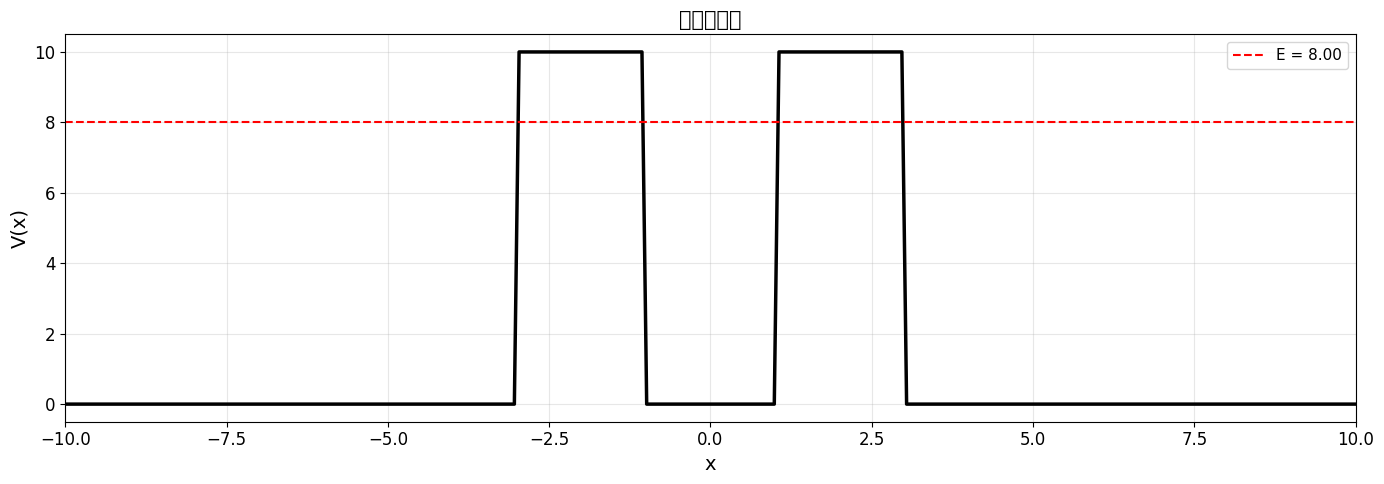

In [3]:
x = p.x
V = np.real(get_potential(x, p, 'double', with_cap=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, V, 'k-', linewidth=2.5)
ax.axhline(p.E_kinetic, color='r', linestyle='--', label=f'E = {p.E_kinetic:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('V(x)')
ax.set_title('双势垒结构')
ax.set_xlim(-10, 10)
ax.legend()
plt.tight_layout()
plt.show()

## 2. 含时演化模拟

In [4]:
result_double = propagate(p, 'double')

In [5]:
print(f'最终透射率: T = {result_double.T_values[-1]:.6f}')
print(f'最终反射率: R = {result_double.R_values[-1]:.6f}')
print(f'概率守恒: ∫|ψ|²dx = {result_double.norm_values[-1]:.8f}')

最终透射率: T = 0.007624
最终反射率: R = 0.988268
概率守恒: ∫|ψ|²dx = 0.99589355


### 波包演化快照 — 观察阱内振荡

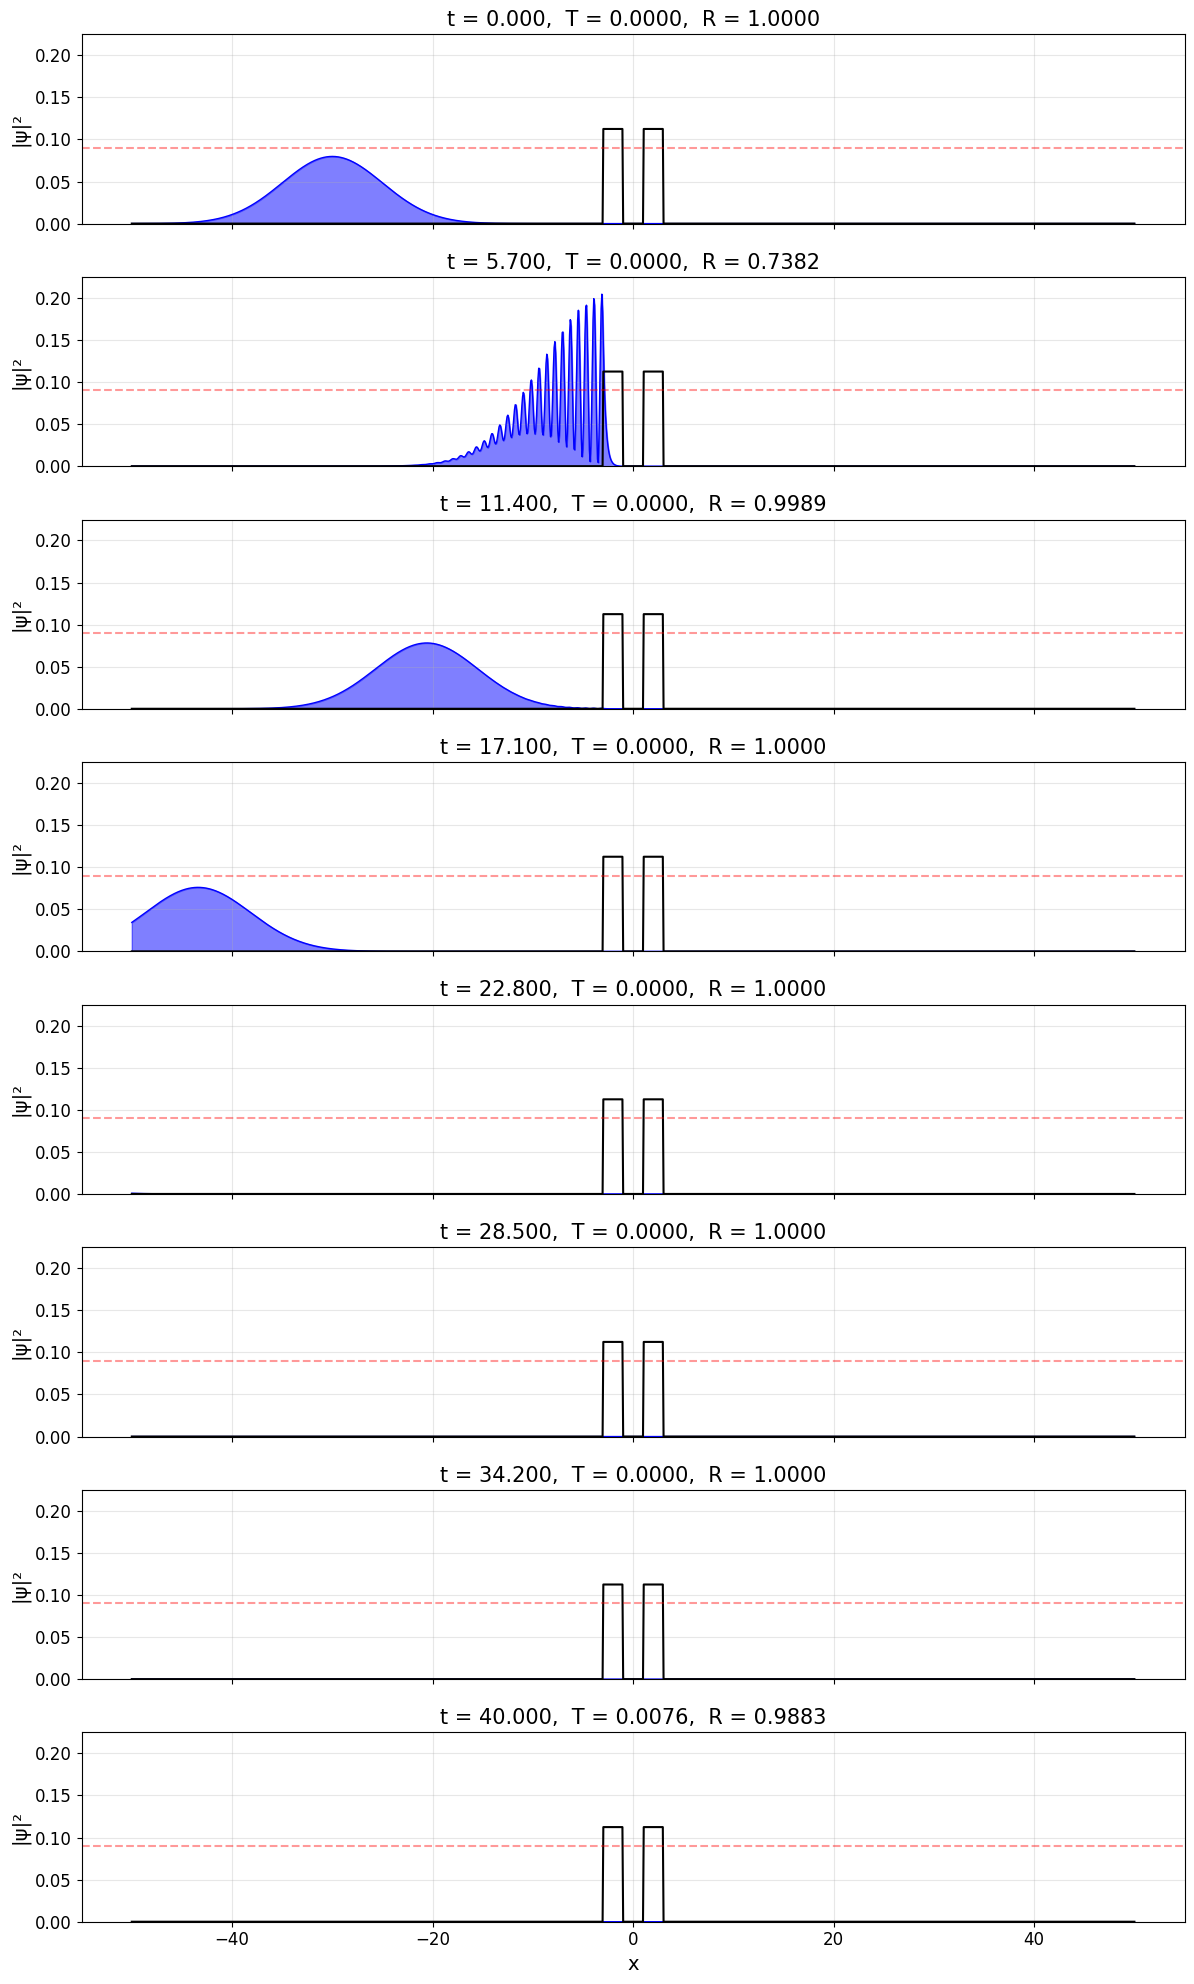

In [6]:
fig = plot_snapshots(result_double, n_snapshots=8, x_range=(-50, 50))
plt.show()

### T/R 演化 — 注意阱内概率的延迟释放

C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 28436 (\N{CJK UNIFIED IDEOGRAPH-6F14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\Op

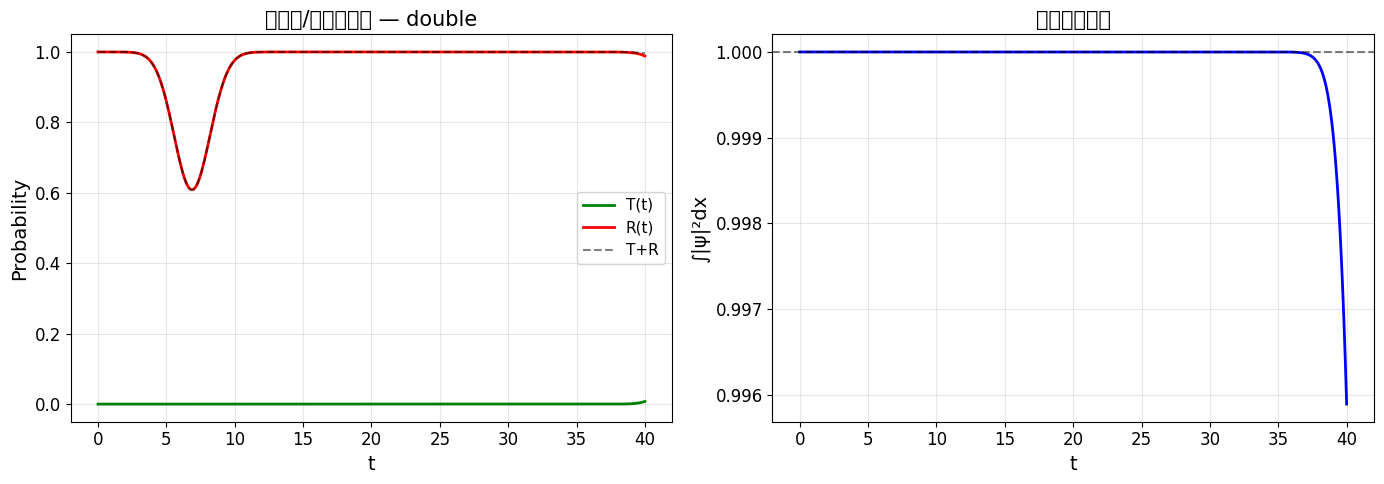

In [7]:
fig = plot_TR_evolution(result_double)
plt.show()

### 动量谱 — 阱内振荡导致动量谱展宽

C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 28436 (\N{CJK UNIFIED IDEOGRAPH-6F14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\Op

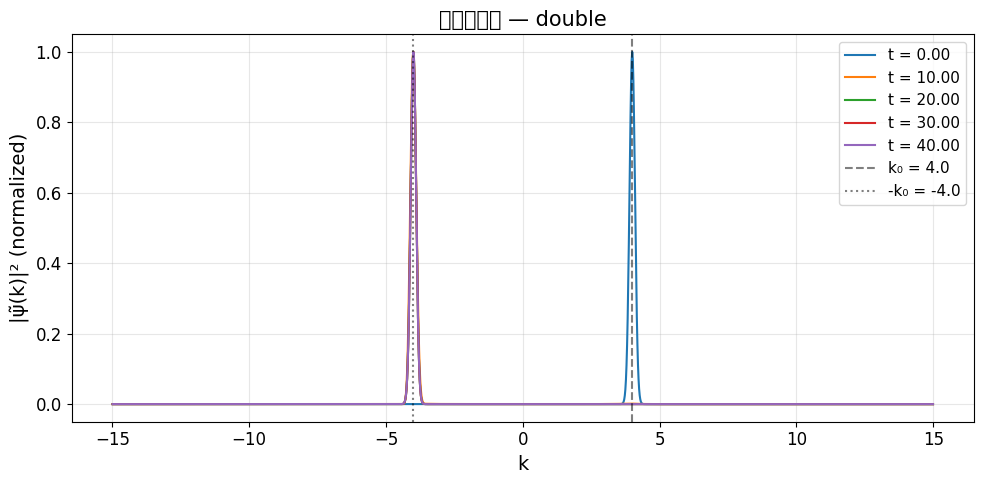

In [8]:
fig = plot_momentum_spectrum(result_double, k_range=(-15, 15))
plt.show()

## 3. 透射率 vs 入射能量 — 寻找共振峰

In [9]:
k0_scan = np.linspace(1.0, 8.0, 30)
T_scan = []

for k0 in k0_scan:
    p_scan = SimParams(V0=10.0, k0=k0, sigma=5.0,
                       b1_a=-3.0, b1_b=-1.0, b2_a=1.0, b2_b=3.0,
                       x0=-25.0)
    res = propagate(p_scan, 'double')
    T_scan.append(res.T_values[-1])
    print(f'k0 = {k0:.2f}, E = {p_scan.E_kinetic:.2f}, T = {res.T_values[-1]:.6f}')

k0 = 1.00, E = 0.50, T = 0.000002
k0 = 1.24, E = 0.77, T = 0.000002
k0 = 1.48, E = 1.10, T = 0.000002
k0 = 1.72, E = 1.49, T = 0.000002
k0 = 1.97, E = 1.93, T = 0.000002
k0 = 2.21, E = 2.44, T = 0.000002
k0 = 2.45, E = 3.00, T = 0.000003
k0 = 2.69, E = 3.62, T = 0.000003
k0 = 2.93, E = 4.30, T = 0.000003
k0 = 3.17, E = 5.03, T = 0.000003
k0 = 3.41, E = 5.83, T = 0.000004
k0 = 3.66, E = 6.68, T = 0.000004
k0 = 3.90, E = 7.59, T = 0.000004
k0 = 4.14, E = 8.56, T = 0.000029
k0 = 4.38, E = 9.59, T = 0.022294
k0 = 4.62, E = 10.68, T = 0.367694
k0 = 4.86, E = 11.82, T = 0.759112
k0 = 5.10, E = 13.02, T = 0.348535
k0 = 5.34, E = 14.28, T = 0.769348
k0 = 5.59, E = 15.60, T = 0.873779
k0 = 5.83, E = 16.98, T = 0.701614
k0 = 6.07, E = 18.42, T = 0.909387
k0 = 6.31, E = 19.91, T = 0.884612
k0 = 6.55, E = 21.46, T = 0.987368
k0 = 6.79, E = 23.07, T = 0.940801
k0 = 7.03, E = 24.74, T = 0.813534
k0 = 7.28, E = 26.47, T = 0.935376
k0 = 7.52, E = 28.25, T = 0.982380
k0 = 7.76, E = 30.10, T = 0.993725


C:\Users\User1\AppData\Local\Temp\ipykernel_7788\3305018385.py:9: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\3305018385.py:9: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\3305018385.py:9: UserWarning: Glyph 22418 (\N{CJK UNIFIED IDEOGRAPH-5792}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\3305018385.py:9: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\3305018385.py:9: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\3305018385.py:9: UserWarning: Glyph 29575 (\N{CJK UNIFIE

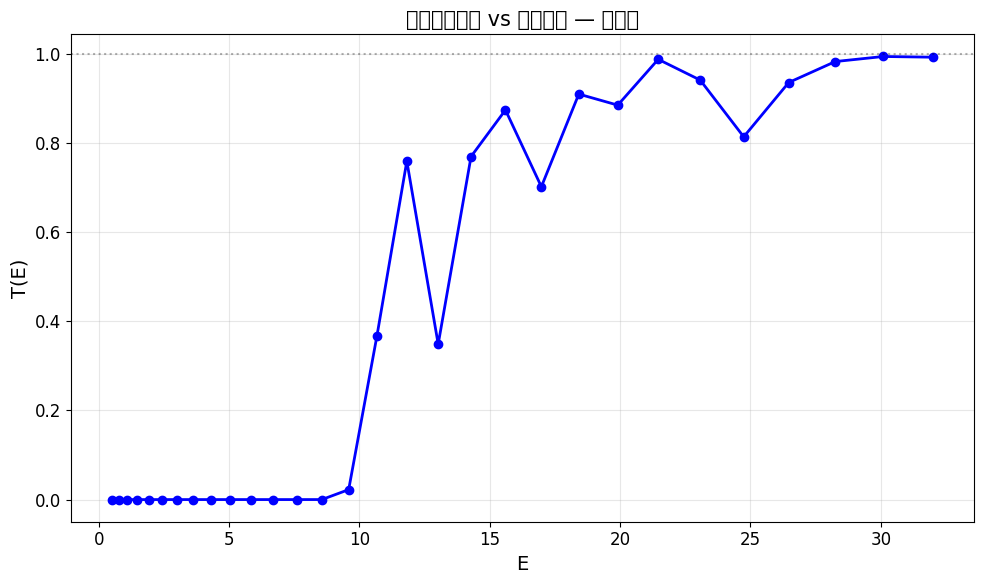

In [10]:
E_scan = [0.5 * k**2 for k in k0_scan]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(E_scan, T_scan, 'bo-', linewidth=2, markersize=6)
ax.axhline(1.0, color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('E')
ax.set_ylabel('T(E)')
ax.set_title('双势垒透射率 vs 入射能量 — 共振峰')
plt.tight_layout()
plt.show()

## 4. 势垒宽度对共振的影响

阱宽度决定准束缚态间距：阱越宽，共振能量越密

C:\Users\User1\AppData\Local\Temp\ipykernel_7788\2110317981.py:23: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\2110317981.py:23: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\2110317981.py:23: UserWarning: Glyph 22418 (\N{CJK UNIFIED IDEOGRAPH-5792}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\2110317981.py:23: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\2110317981.py:23: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_7788\2110317981.py:23: UserWarning: Glyph 38449 (\N{CJK 

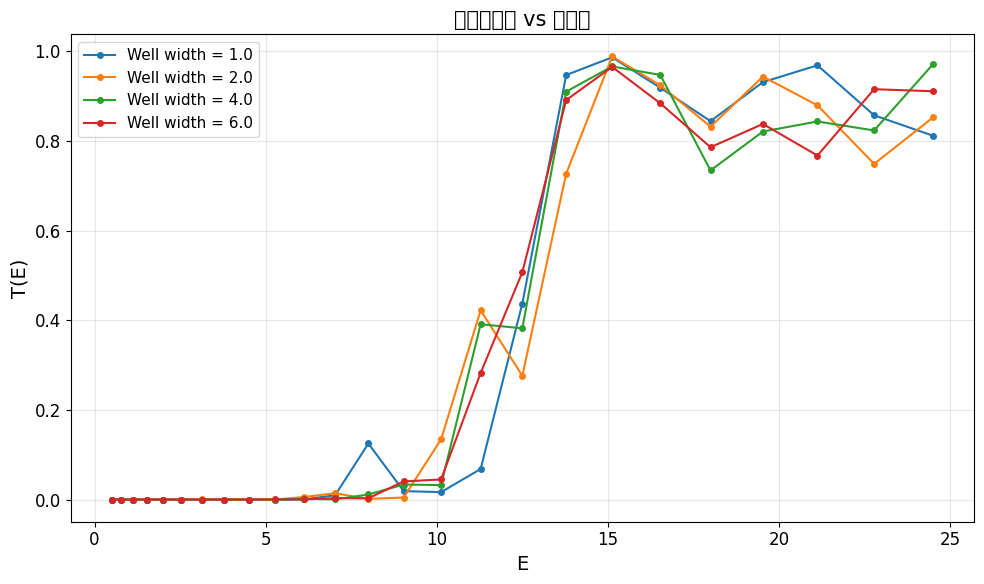

In [11]:
well_widths = [1.0, 2.0, 4.0, 6.0]

fig, ax = plt.subplots(figsize=(10, 6))
for ww in well_widths:
    p_w = SimParams(V0=10.0, k0=4.0, sigma=5.0, x0=-25.0,
                    b1_a=-1.0-ww/2, b1_b=-ww/2,
                    b2_a=ww/2, b2_b=1.0+ww/2)
    k0_s = np.linspace(1.0, 7.0, 25)
    T_s = []
    for k0 in k0_s:
        p_s = SimParams(V0=10.0, k0=k0, sigma=5.0, x0=-25.0,
                        b1_a=-1.0-ww/2, b1_b=-ww/2,
                        b2_a=ww/2, b2_b=1.0+ww/2)
        res = propagate(p_s, 'double')
        T_s.append(res.T_values[-1])
    E_s = [0.5*k**2 for k in k0_s]
    ax.plot(E_s, T_s, '-o', markersize=4, linewidth=1.5, label=f'Well width = {ww:.1f}')

ax.set_xlabel('E')
ax.set_ylabel('T(E)')
ax.set_title('双势垒共振 vs 阱宽度')
ax.legend()
plt.tight_layout()
plt.show()